In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/application_train.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 307,511 rows × 122 columns


In [2]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns  : {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")
print(f"\nCategorical columns:\n{cat_cols}")

Numerical columns  : 106
Categorical columns: 16

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


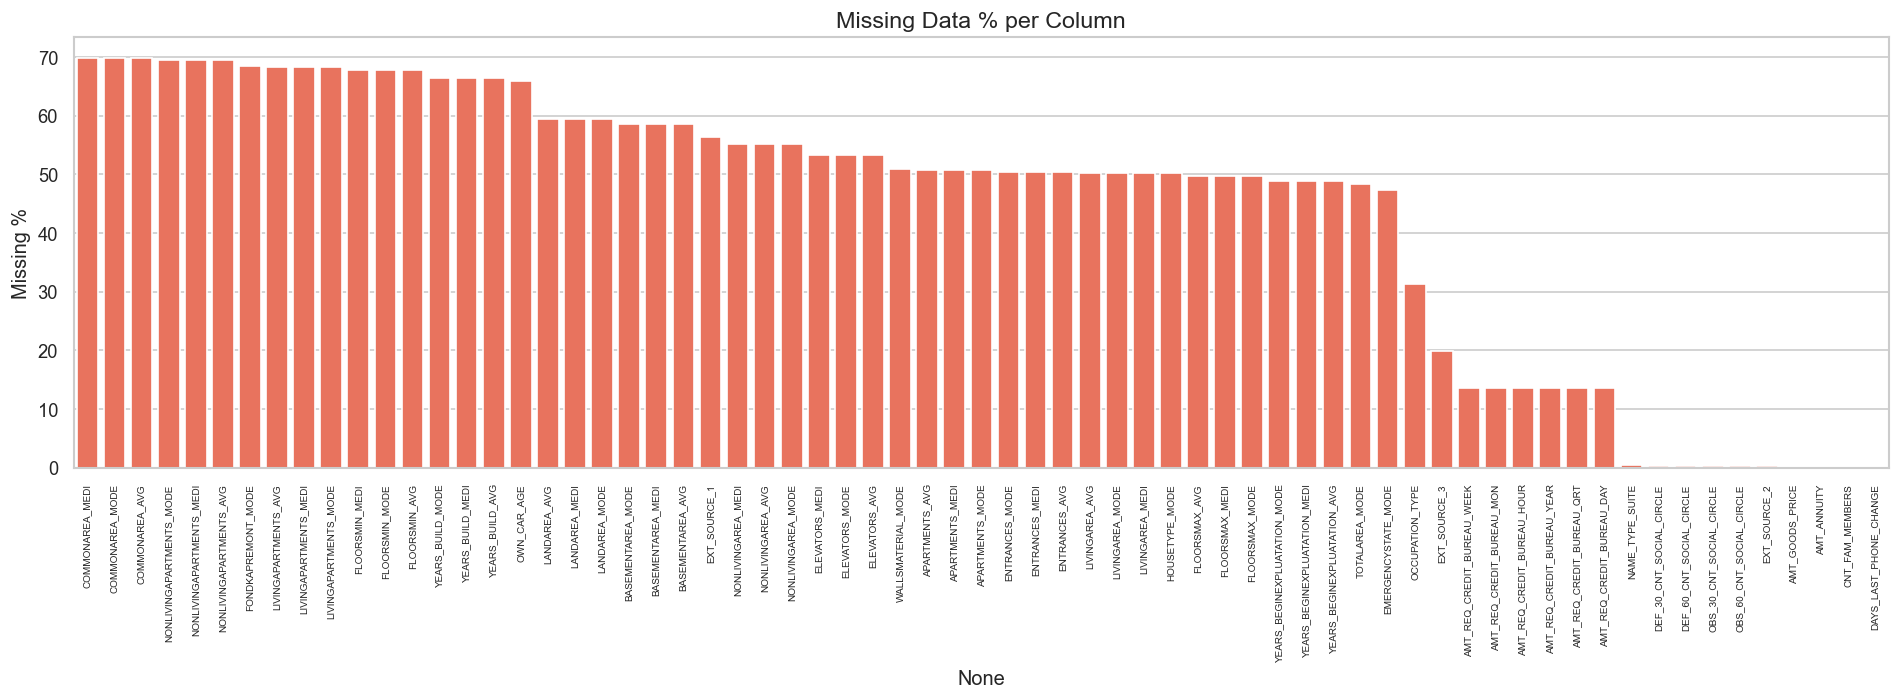


Columns with >50% missing: 41
Columns with >30% missing: 50


In [3]:
# Visual heatmap of missing data
plt.figure(figsize=(16, 6))
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

sns.barplot(x=missing_pct.index, y=missing_pct.values, color='tomato')
plt.xticks(rotation=90, fontsize=6)
plt.title('Missing Data % per Column', fontsize=14)
plt.ylabel('Missing %')
plt.tight_layout()
plt.savefig('../data/missing_values.png')
plt.show()

print(f"\nColumns with >50% missing: {(missing_pct > 50).sum()}")
print(f"Columns with >30% missing: {(missing_pct > 30).sum()}")

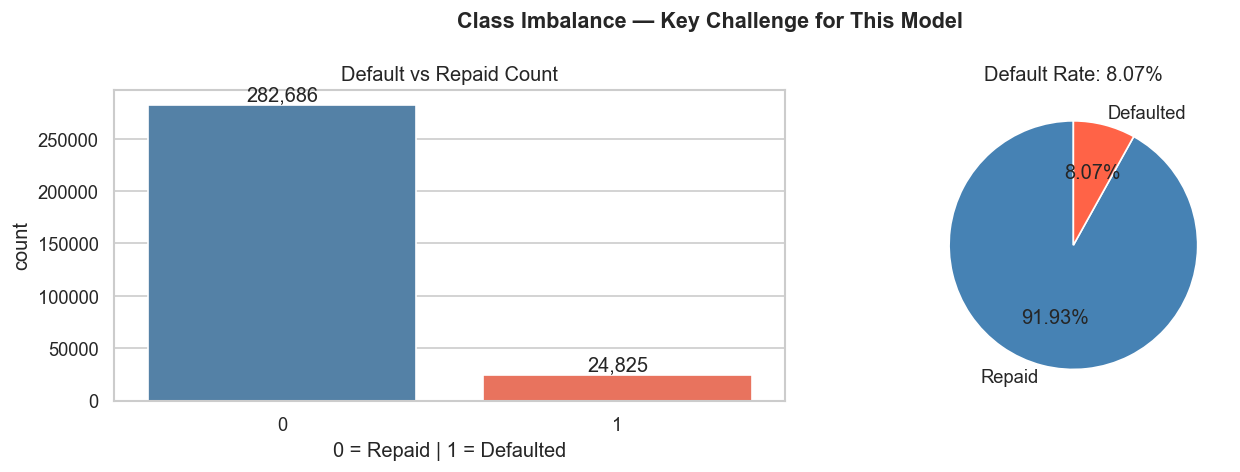

Business Insight:
   Only 8.07% of applicants default.
   This class imbalance means accuracy is misleading.
   We must use AUC-ROC, Precision-Recall as metrics.


In [5]:
target = df['TARGET'].value_counts()
default_rate = df['TARGET'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.countplot(x='TARGET', data=df,
              palette=['steelblue','tomato'], ax=axes[0])
axes[0].set_title('Default vs Repaid Count')
axes[0].set_xlabel('0 = Repaid | 1 = Defaulted')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

# Pie chart
axes[1].pie(target, labels=['Repaid','Defaulted'],
            autopct='%1.2f%%', colors=['steelblue','tomato'],
            startangle=90)
axes[1].set_title(f'Default Rate: {default_rate:.2f}%')

plt.suptitle('Class Imbalance — Key Challenge for This Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/class_imbalance.png')
plt.show()

# Business insight
print("Business Insight:")
print(f"   Only {default_rate:.2f}% of applicants default.")
print("   This class imbalance means accuracy is misleading.")
print("   We must use AUC-ROC, Precision-Recall as metrics.")

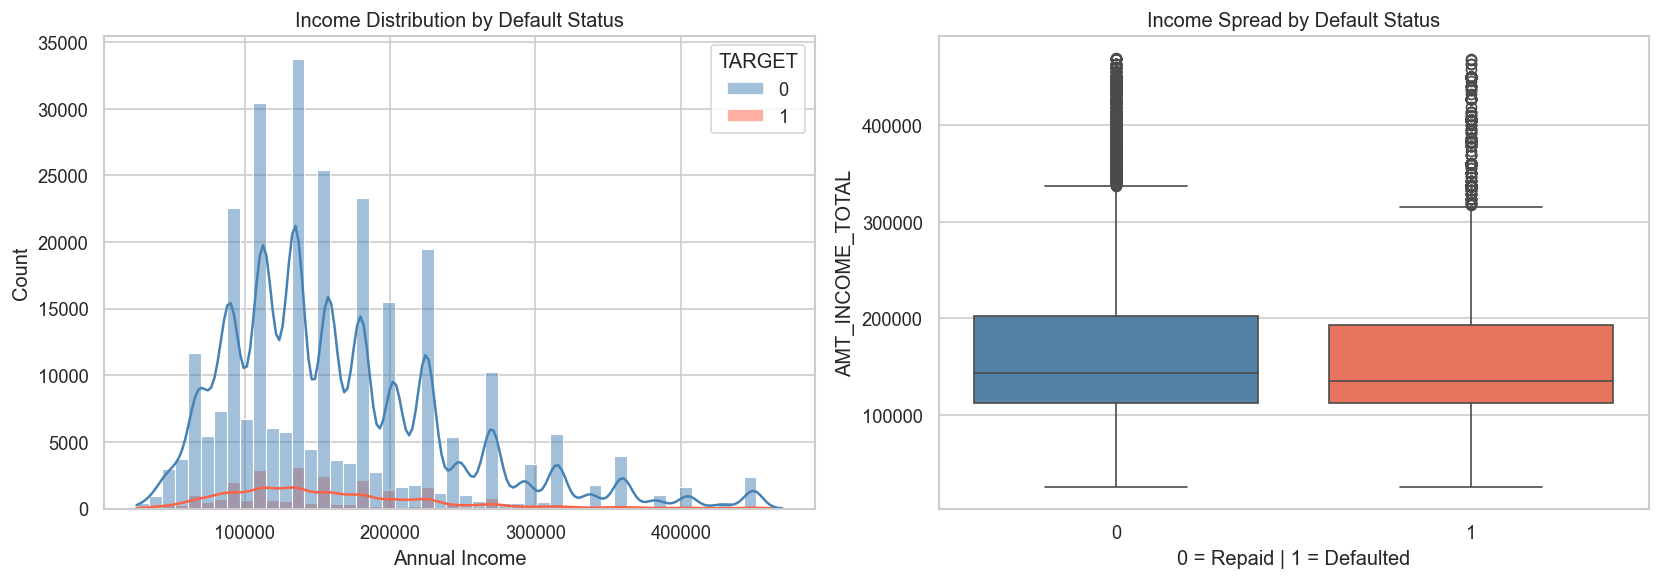

💡 Average Income:
TARGET
0      ₹169,078
1      ₹165,612
Name: AMT_INCOME_TOTAL, dtype: object


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Remove extreme outliers for visualization
income_cap = df['AMT_INCOME_TOTAL'].quantile(0.99)
df_plot = df[df['AMT_INCOME_TOTAL'] < income_cap]

# Distribution
sns.histplot(data=df_plot, x='AMT_INCOME_TOTAL',
             hue='TARGET', kde=True,
             palette=['steelblue','tomato'],
             ax=axes[0], bins=50)
axes[0].set_title('Income Distribution by Default Status')
axes[0].set_xlabel('Annual Income')

# Boxplot
sns.boxplot(data=df_plot, x='TARGET',
            y='AMT_INCOME_TOTAL',
            palette=['steelblue','tomato'], ax=axes[1])
axes[1].set_title('Income Spread by Default Status')
axes[1].set_xlabel('0 = Repaid | 1 = Defaulted')

plt.tight_layout()
plt.savefig('../data/income_vs_default.png')
plt.show()

# Stats
print("💡 Average Income:")
print(df.groupby('TARGET')['AMT_INCOME_TOTAL'].mean().apply(
    lambda x: f"  ₹{x:,.0f}"))

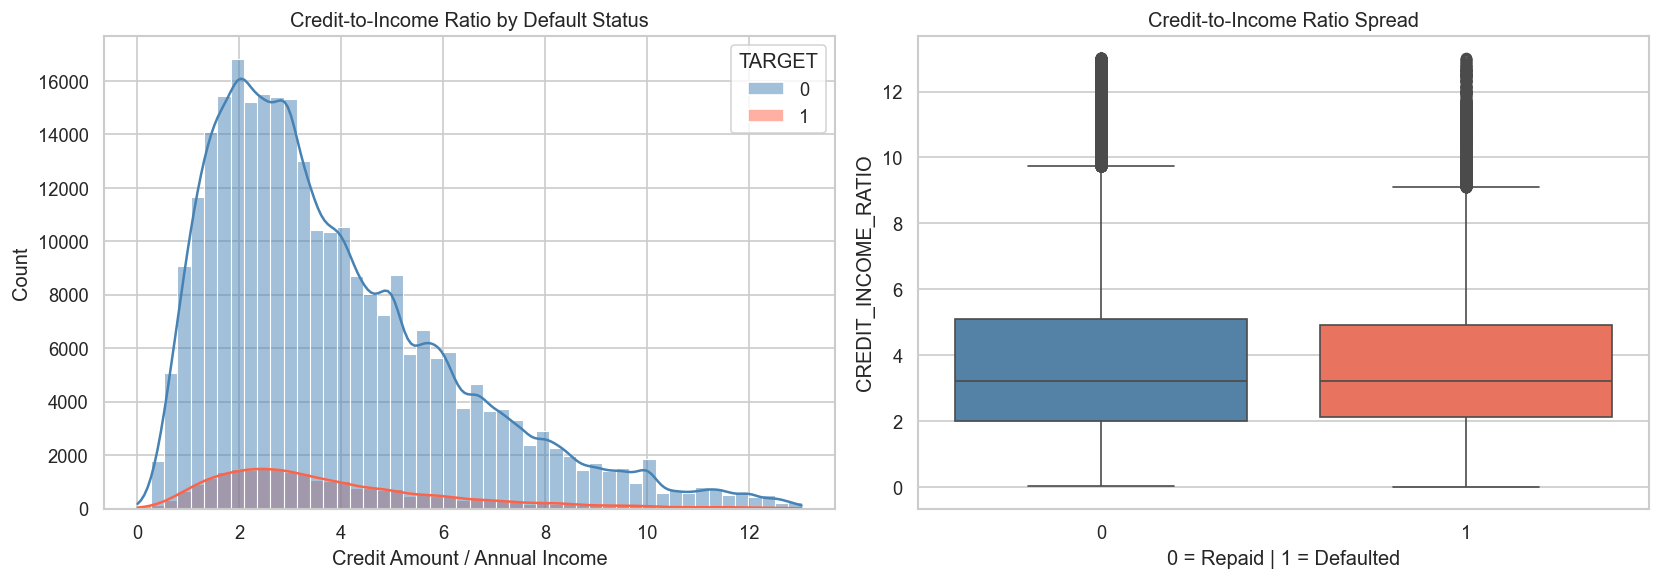

💡 Business Insight:
   Higher credit-to-income ratio = higher default risk
   This engineered feature will be powerful in our model


In [7]:
# Credit-to-Income ratio — key risk indicator
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratio_cap = df['CREDIT_INCOME_RATIO'].quantile(0.99)
df_plot   = df[df['CREDIT_INCOME_RATIO'] < ratio_cap]

sns.histplot(data=df_plot, x='CREDIT_INCOME_RATIO',
             hue='TARGET', kde=True,
             palette=['steelblue','tomato'],
             ax=axes[0], bins=50)
axes[0].set_title('Credit-to-Income Ratio by Default Status')
axes[0].set_xlabel('Credit Amount / Annual Income')

sns.boxplot(data=df_plot, x='TARGET',
            y='CREDIT_INCOME_RATIO',
            palette=['steelblue','tomato'], ax=axes[1])
axes[1].set_title('Credit-to-Income Ratio Spread')
axes[1].set_xlabel('0 = Repaid | 1 = Defaulted')

plt.tight_layout()
plt.savefig('../data/credit_income_ratio.png')
plt.show()

print("💡 Business Insight:")
print("   Higher credit-to-income ratio = higher default risk")
print("   This engineered feature will be powerful in our model")

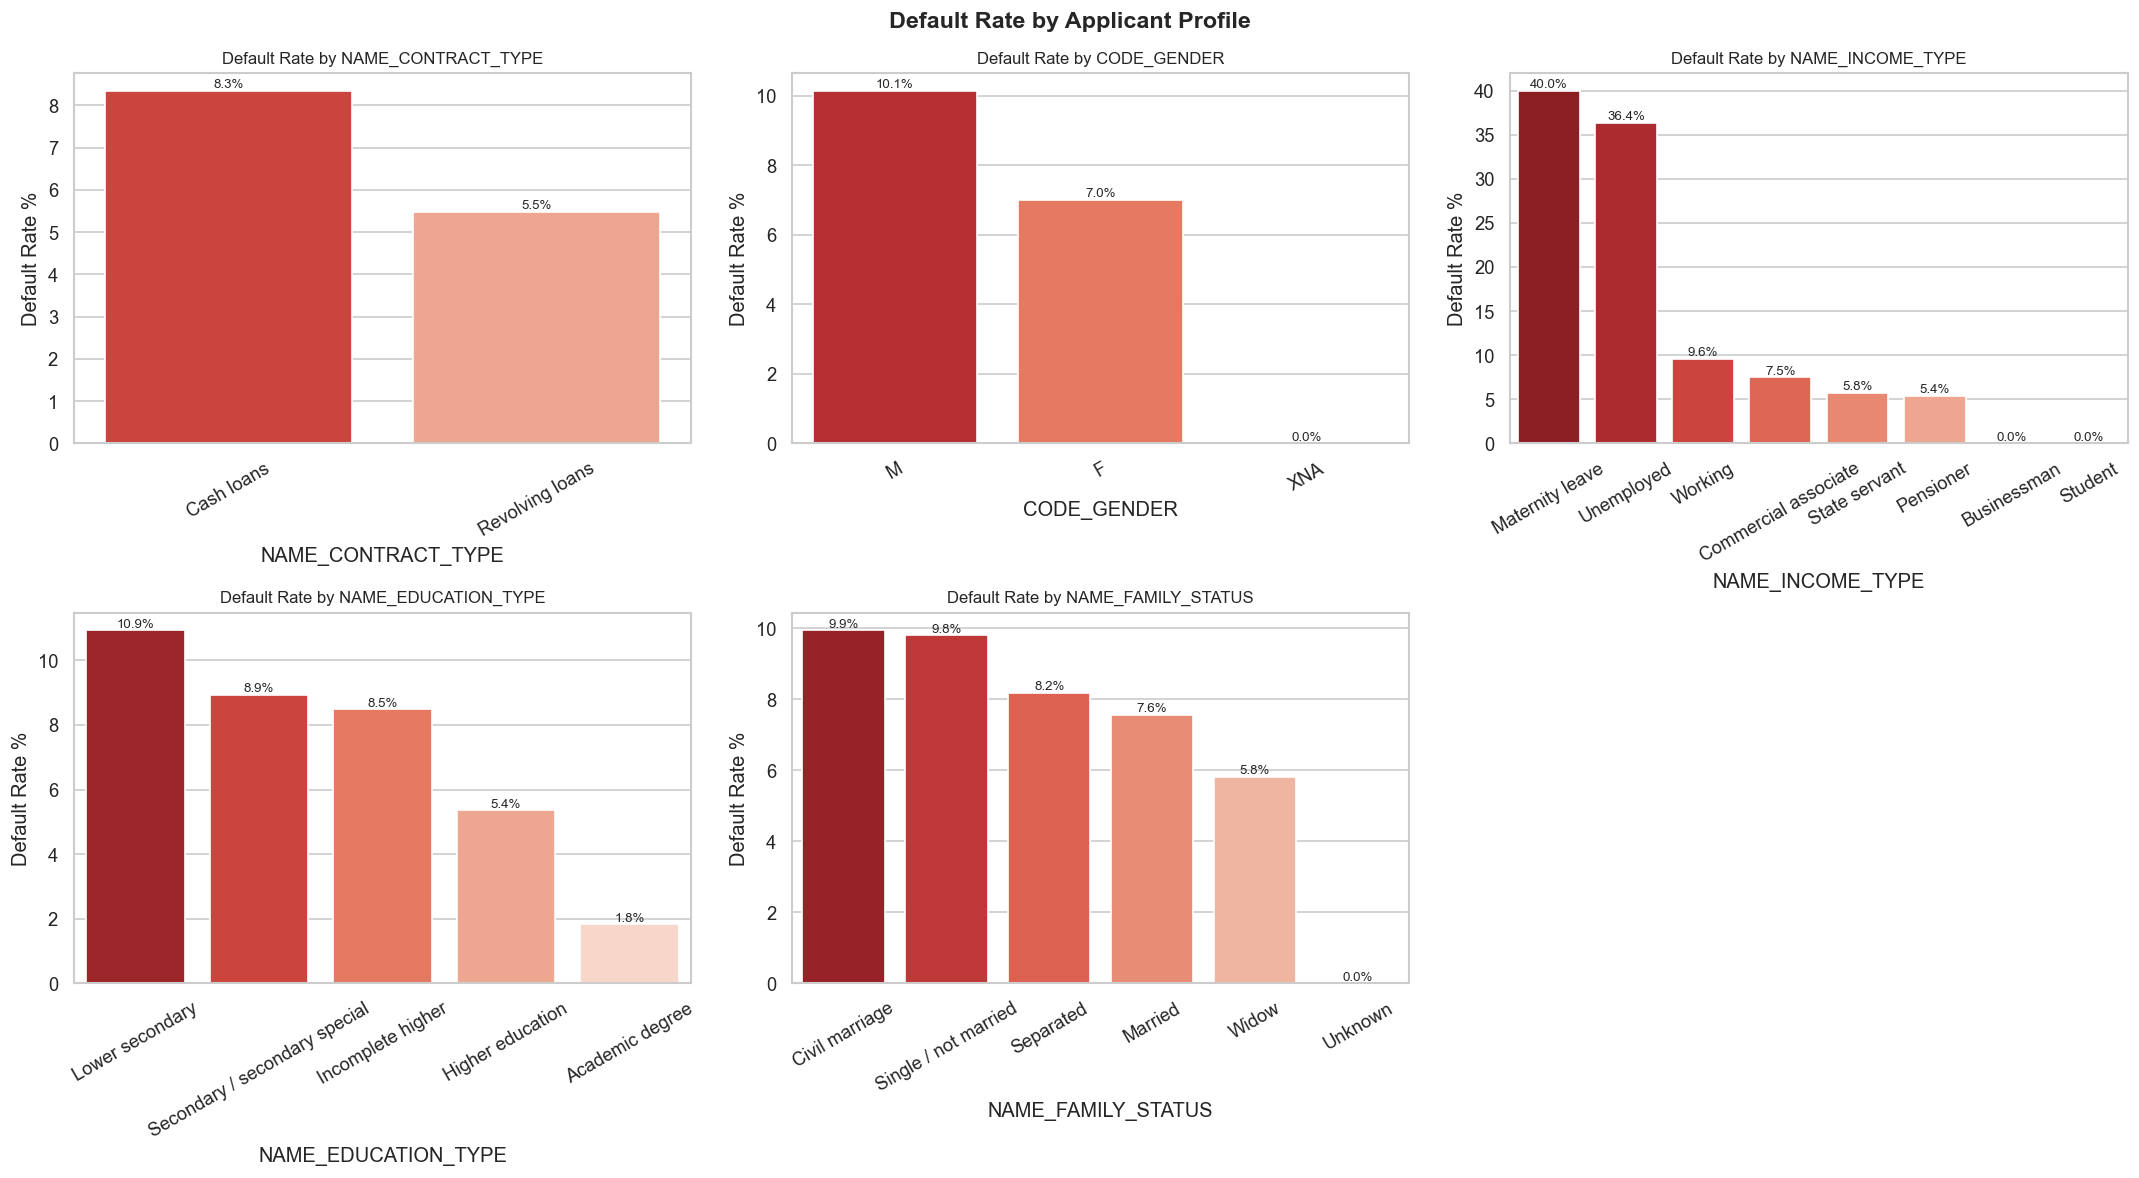

In [8]:
# Top categorical features vs default rate
cat_features = ['NAME_CONTRACT_TYPE', 'CODE_GENDER',
                'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
                'NAME_FAMILY_STATUS']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    default_rates = df.groupby(col)['TARGET'].mean() * 100
    default_rates = default_rates.sort_values(ascending=False)

    sns.barplot(x=default_rates.index,
                y=default_rates.values,
                palette='Reds_r', ax=axes[i])
    axes[i].set_title(f'Default Rate by {col}', fontsize=10)
    axes[i].set_ylabel('Default Rate %')
    axes[i].tick_params(axis='x', rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width()/2,
                          p.get_height()),
                         ha='center', va='bottom', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Default Rate by Applicant Profile',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/categorical_default_rates.png')
plt.show()

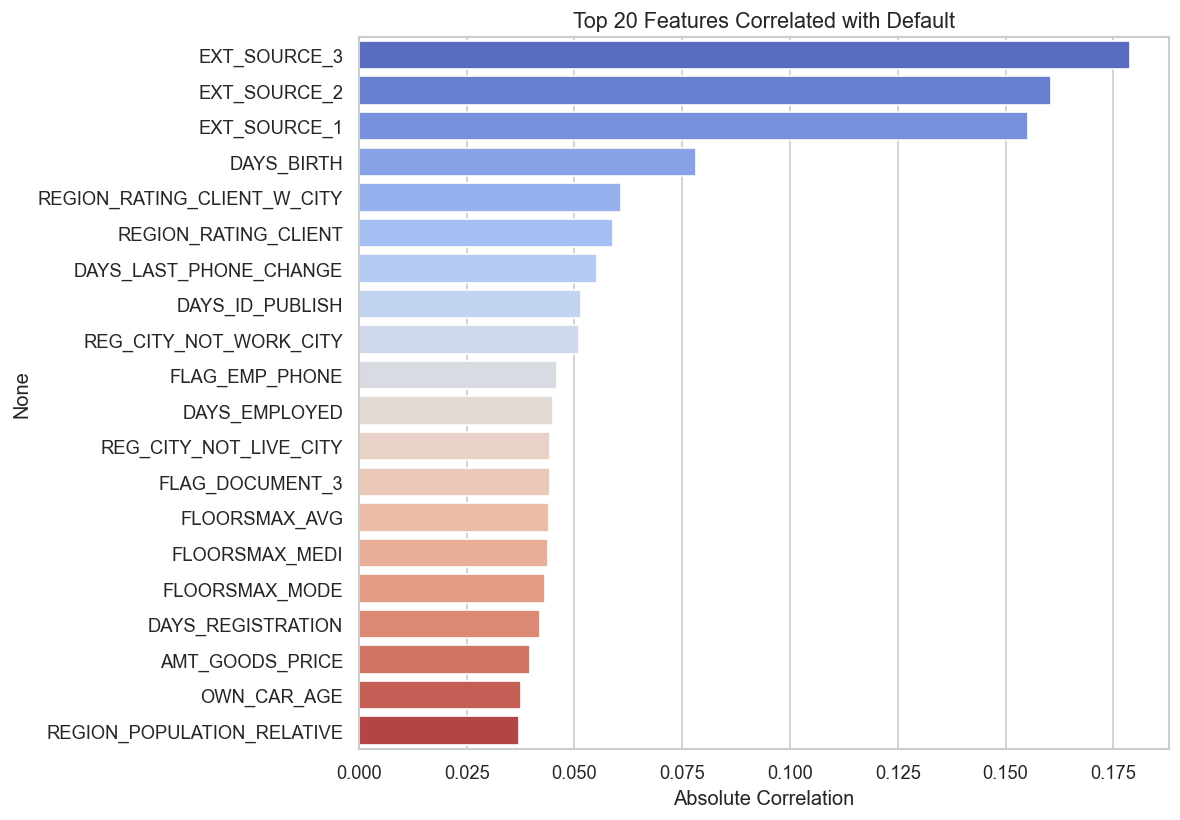

In [10]:
# Top correlated numerical features with TARGET
correlations = df[num_cols].corr()['TARGET'].drop('TARGET')
correlations = correlations.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x=correlations.values,
            y=correlations.index,
            palette='coolwarm')
plt.title('Top 20 Features Correlated with Default', fontsize=13)
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.savefig('../data/feature_correlations.png')
plt.show()


In [12]:
print("=" * 55)
print("       EDA SUMMARY — BUSINESS INSIGHTS")
print("=" * 55)

print(f"""
Dataset    : {df.shape[0]:,} loan applications
Default Rate: {df['TARGET'].mean()*100:.2f}% (Class Imbalance!)

Key Risk Profiles:
   • Higher credit-to-income ratio → more likely to default
   • Lower education level → higher default rate
   • Certain contract types carry more risk

Data Challenges:
   • {(df.isnull().mean() > 0.3).sum()} columns have >30% missing values
   • Severe class imbalance (92% vs 8%)
   • Outliers in income & credit amounts

Next Steps (Phase 3):
   • Drop high-missing columns
   • Encode categoricals
   • Engineer new features
   • Handle class imbalance with SMOTE/scale_pos_weight
""")

       EDA SUMMARY — BUSINESS INSIGHTS

Dataset    : 307,511 loan applications
Default Rate: 8.07% (Class Imbalance!)

Key Risk Profiles:
   • Higher credit-to-income ratio → more likely to default
   • Lower education level → higher default rate
   • Certain contract types carry more risk

Data Challenges:
   • 50 columns have >30% missing values
   • Severe class imbalance (92% vs 8%)
   • Outliers in income & credit amounts

Next Steps (Phase 3):
   • Drop high-missing columns
   • Encode categoricals
   • Engineer new features
   • Handle class imbalance with SMOTE/scale_pos_weight

